# Construction PPE Detection — YOLO11 nano

Detecting hard hats, vests, gloves, boots and goggles on construction sites — and,
more importantly, when they're **missing**.

**YOLO11n**: 2.6 M parameters, 6.5 GFLOPs, 39.5 mAP on COCO. The most widely used nano detector and the best-supported one on Apple Silicon — this is the control that the YOLO26n result in notebook 01 is measured against.

A note on what this notebook *isn't*: RT-DETR-nano. That checkpoint does not exist — Ultralytics ships RT-DETR only as `rtdetr-l.pt` (~32 M params, ~103 GFLOPs) and `rtdetr-x.pt`, roughly 13x a nano model. That fails both the minimal-size and realtime goals here.

### This notebook runs anywhere

Every compute step branches on one boolean, `GPU_AVAILABLE`:

| | GPU present | No GPU |
|---|---|---|
| Device | CUDA (NVIDIA) or MPS (Apple) | CPU |
| Image size | 640 px | 416 px |
| Batch | 16–32 | 4 |
| Epochs | 59 | 10 (capped) |
| Expected | ~50 s/epoch | ~10–20 min/epoch |

Developed on an Apple M2 Pro (16 GB, Metal). Verified to fall back cleanly to CPU.

### It also runs offline

Corporate networks often block GitHub, which is where both the base weights and the
dataset come from. So:

- The pretrained checkpoint lives in **`og_model/`** — committed with the code.
- Trained weights are written to **`trained_model/`**.
- Nothing downloads unless `ALLOW_DOWNLOADS = True` **and** the file is actually missing.

Copy the whole folder — including `og_model/` and `dataset/` — and it will run with the
network completely off.

## 1. Imports and offline configuration

Two switches at the top control everything about how this notebook behaves in a
restricted environment.

In [1]:
import os, sys, time, json, platform, shutil, logging, warnings
from pathlib import Path
from collections import Counter

# ---------------------------------------------------------------------------
# Set this to False on a machine where GitHub is blocked. Nothing will be
# fetched; if a required file is missing you get a clear error telling you which
# one, instead of a confusing network timeout deep inside Ultralytics.
ALLOW_DOWNLOADS = True
# ---------------------------------------------------------------------------

# Must be set before torch is imported: some ops in the YOLO loss have no Metal
# kernel, and without this the run dies mid-epoch with NotImplementedError.
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("OMP_NUM_THREADS", "4")
os.environ.setdefault("MKL_NUM_THREADS", "4")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Stop Ultralytics phoning home for version checks / analytics.
os.environ.setdefault("YOLO_OFFLINE", "true" if not ALLOW_DOWNLOADS else "false")
os.environ.setdefault("WANDB_DISABLED", "true")
os.environ.setdefault("COMET_MODE", "DISABLED")

warnings.filterwarnings("ignore", message=".*does not have a deterministic implementation.*")
warnings.filterwarnings("ignore", category=FutureWarning)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import ultralytics
from ultralytics import YOLO, RTDETR
from ultralytics.utils import LOGGER

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

print("Python      ", sys.version.split()[0])
print("PyTorch     ", torch.__version__)
print("Ultralytics ", ultralytics.__version__)
print("OpenCV      ", cv2.__version__)
print("NumPy       ", np.__version__)
print()
print("Downloads allowed:", ALLOW_DOWNLOADS)

Python       3.14.4
PyTorch      2.14.0
Ultralytics  8.4.163
OpenCV       5.0.0
NumPy        2.3.5

Downloads allowed: True


## 2. Is there a GPU?

This is the decision everything else branches on. `GPU_AVAILABLE` is set once here
and every later cell reads it — no cell guesses independently.

Note MPS is checked via `getattr`, because `torch.backends.mps` doesn't exist at all on
older builds and on some Windows wheels; a bare attribute access would raise there.

In [2]:
def host_info():
    """Hardware summary that works on macOS, Windows and Linux."""
    info = {"os": f"{platform.system()} {platform.release()}",
            "arch": platform.machine(),
            "cpu": platform.processor() or platform.machine(),
            "cores": os.cpu_count(), "ram_gb": None}
    try:
        if platform.system() == "Darwin":
            import subprocess
            q = lambda k: subprocess.check_output(["sysctl", "-n", k], text=True).strip()
            info["cpu"] = q("machdep.cpu.brand_string")
            info["ram_gb"] = round(int(q("hw.memsize")) / 1024**3)
        elif platform.system() == "Linux":
            for ln in Path("/proc/meminfo").read_text().splitlines():
                if ln.startswith("MemTotal"):
                    info["ram_gb"] = round(int(ln.split()[1]) / 1024**2); break
        elif platform.system() == "Windows":
            import ctypes
            class MS(ctypes.Structure):
                _fields_ = [("dwLength", ctypes.c_ulong), ("dwMemoryLoad", ctypes.c_ulong),
                            ("ullTotalPhys", ctypes.c_ulonglong), ("ullAvailPhys", ctypes.c_ulonglong),
                            ("ullTotalPageFile", ctypes.c_ulonglong), ("ullAvailPageFile", ctypes.c_ulonglong),
                            ("ullTotalVirtual", ctypes.c_ulonglong), ("ullAvailVirtual", ctypes.c_ulonglong),
                            ("ullAvailExtendedVirtual", ctypes.c_ulonglong)]
            st = MS(); st.dwLength = ctypes.sizeof(MS)
            ctypes.windll.kernel32.GlobalMemoryStatusEx(ctypes.byref(st))
            info["ram_gb"] = round(st.ullTotalPhys / 1024**3)
    except Exception:
        pass
    return info

HOST = host_info()
print("=" * 66)
print("  HOST")
print("=" * 66)
print(f"  OS     : {HOST['os']} ({HOST['arch']})")
print(f"  CPU    : {HOST['cpu']}")
print(f"  Cores  : {HOST['cores']}")
print(f"  RAM    : {HOST['ram_gb'] or '?'} GB")
print("=" * 66)
print()

# --- the one boolean everything else depends on --------------------------
HAS_CUDA = torch.cuda.is_available()
HAS_MPS  = bool(getattr(torch.backends, "mps", None)) and torch.backends.mps.is_available()
GPU_AVAILABLE = HAS_CUDA or HAS_MPS

if GPU_AVAILABLE:
    if HAS_CUDA:
        GPU_TYPE  = "cuda"
        DEVICE    = "0"
        GPU_NAME  = torch.cuda.get_device_name(0)
        GPU_MEM   = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"  GPU FOUND : {GPU_NAME}")
        print(f"              {GPU_MEM:.1f} GB VRAM, CUDA {torch.version.cuda}")
    else:
        GPU_TYPE  = "mps"
        DEVICE    = "mps"
        GPU_NAME  = "Apple Silicon GPU (Metal)"
        GPU_MEM   = (HOST.get("ram_gb") or 16) * 0.4   # unified memory, shared with the OS
        print(f"  GPU FOUND : {GPU_NAME}")
        print(f"              unified memory, ~{GPU_MEM:.1f} GB usable for training")
    # Don't take the flag's word for it — actually compute something.
    t0 = time.perf_counter()
    _ = torch.randn(2048, 2048, device=GPU_TYPE) @ torch.randn(2048, 2048, device=GPU_TYPE)
    torch.cuda.synchronize() if HAS_CUDA else torch.mps.synchronize()
    print(f"              verified: 2048x2048 matmul in {(time.perf_counter()-t0)*1000:.0f} ms")
else:
    GPU_TYPE = None
    DEVICE   = "cpu"
    GPU_NAME = "none"
    GPU_MEM  = 0
    print("  NO GPU    : training will run on CPU.")
    print("              This works, but expect roughly 10-20 minutes per epoch")
    print("              instead of under a minute. Settings are reduced below to")
    print("              keep the total time sane.")

print()
print(f"  GPU_AVAILABLE = {GPU_AVAILABLE}   ->   device '{DEVICE}'")

  HOST
  OS     : Darwin 25.6.0 (arm64)
  CPU    : Apple M2 Pro
  Cores  : 10
  RAM    : 16 GB

  GPU FOUND : Apple Silicon GPU (Metal)
              unified memory, ~6.4 GB usable for training
              verified: 2048x2048 matmul in 141 ms

  GPU_AVAILABLE = True   ->   device 'mps'


## 3. Folder layout

`og_model/` holds the pristine downloaded checkpoint, `trained_model/` holds what comes
out of training. Keeping them apart matters: Ultralytics writes weights into
`runs/<name>/weights/`, and a later run with `exist_ok=True` overwrites them in place.
Copying the result out means a good run can't be lost to a careless re-run.

In [3]:
# Find the project root whether the kernel started here or one level up.
PROJECT = Path.cwd()
if not (PROJECT / "scripts").exists() and (PROJECT.parent / "scripts").exists():
    PROJECT = PROJECT.parent

OG_MODEL_DIR    = PROJECT / "og_model"        # pristine pretrained weights
TRAINED_DIR     = PROJECT / "trained_model"   # our trained weights
DATA_DIR        = PROJECT / "dataset"
DATA_ROOT       = DATA_DIR / "construction-ppe"
DATA_YAML       = DATA_DIR / "construction-ppe.yaml"
RUNS_DIR        = PROJECT / "runs"
PRED_ROOT       = PROJECT / "predictions"
EXPORT_DIR      = PROJECT / "exports"

for d in (OG_MODEL_DIR, TRAINED_DIR, DATA_DIR, RUNS_DIR, PRED_ROOT, EXPORT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Ultralytics resolves a RELATIVE project= against its own settings['runs_dir']
# (default ~/runs), not the working directory. Without pinning these, output
# silently lands outside the project and these folders stay empty.
from ultralytics import settings as ultra_settings
ultra_settings.update({"datasets_dir": str(DATA_DIR),
                       "runs_dir": str(RUNS_DIR),
                       "weights_dir": str(OG_MODEL_DIR)})

for label, path in [("og_model", OG_MODEL_DIR), ("trained_model", TRAINED_DIR),
                    ("dataset", DATA_DIR), ("runs", RUNS_DIR),
                    ("predictions", PRED_ROOT), ("exports", EXPORT_DIR)]:
    print(f"  {label:<14} {path}")

  og_model       /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/og_model
  trained_model  /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/trained_model
  dataset        /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/dataset
  runs           /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/runs
  predictions    /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/predictions
  exports        /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/exports


## 4. The pretrained checkpoint

Ultralytics normally downloads `yolo26n.pt` from GitHub on first use. On a machine where
GitHub is blocked that fails with an opaque network error partway into `YOLO(...)`.

So the file is kept in `og_model/` and loaded by **explicit path**. The download below
only ever runs if the file is missing *and* `ALLOW_DOWNLOADS` is True.

In [4]:
MODEL_NAME = "yolo11n.pt"
OG_WEIGHTS = OG_MODEL_DIR / MODEL_NAME

if OG_WEIGHTS.exists():
    print(f"Found local checkpoint: {OG_WEIGHTS}")
    print(f"  size: {OG_WEIGHTS.stat().st_size/1024**2:.2f} MB")
    print("  no download needed.")

elif ALLOW_DOWNLOADS:
    print(f"{MODEL_NAME} not in og_model/ — downloading once...")
    URL = f"https://github.com/ultralytics/assets/releases/download/v8.3.0/{MODEL_NAME}"
    try:
        import urllib.request
        urllib.request.urlretrieve(URL, OG_WEIGHTS)
        print(f"  saved -> {OG_WEIGHTS} ({OG_WEIGHTS.stat().st_size/1024**2:.2f} MB)")
    except Exception as e:
        # Fall back to letting Ultralytics fetch it, then keep a copy for next time.
        print(f"  direct download failed ({str(e)[:80]}); trying via Ultralytics...")
        _tmp = YOLO(MODEL_NAME)
        src = Path(_tmp.ckpt_path)
        shutil.copy2(src, OG_WEIGHTS)
        print(f"  saved -> {OG_WEIGHTS}")

else:
    raise FileNotFoundError(
        f"\n{'='*70}\n"
        f"  {MODEL_NAME} is missing and ALLOW_DOWNLOADS is False.\n\n"
        f"  Expected at: {OG_WEIGHTS}\n\n"
        f"  On a machine with internet, run this notebook once to populate\n"
        f"  og_model/, then copy that folder across with the code.\n"
        f"{'='*70}"
    )

print(f"\nBase weights ready: {OG_WEIGHTS.name}")

Found local checkpoint: /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/og_model/yolo11n.pt
  size: 5.35 MB
  no download needed.

Base weights ready: yolo11n.pt


## 5. The dataset

Same principle. The images ship in `dataset/`; the download is a fallback, not the
normal path. The YAML is **generated here** rather than shipped, because it needs an
absolute path that's only correct on the machine it's running on.

In [5]:
CLASS_NAMES = {0: "helmet", 1: "gloves", 2: "vest", 3: "boots", 4: "goggles",
               5: "none", 6: "Person", 7: "no_helmet", 8: "no_goggle",
               9: "no_gloves", 10: "no_boots"}
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if (DATA_ROOT / "images" / "train").exists():
    print(f"Dataset found: {DATA_ROOT}")

elif ALLOW_DOWNLOADS:
    print("Dataset missing — downloading (~170 MB, one time)...")
    import urllib.request, zipfile, tempfile
    URL = "https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip"
    with tempfile.TemporaryDirectory() as tmp:
        z = Path(tmp) / "ppe.zip"
        urllib.request.urlretrieve(URL, z)
        with zipfile.ZipFile(z) as zf:
            zf.extractall(DATA_ROOT)
    inner = DATA_ROOT / "construction-ppe"   # archive is sometimes nested
    if inner.exists():
        for item in inner.iterdir():
            item.rename(DATA_ROOT / item.name)
        inner.rmdir()
    print("  done.")

else:
    raise FileNotFoundError(
        f"\n{'='*70}\n"
        f"  Dataset missing and ALLOW_DOWNLOADS is False.\n\n"
        f"  Expected: {DATA_ROOT / 'images' / 'train'}\n\n"
        f"  Copy the dataset/ folder across with the code.\n"
        f"{'='*70}"
    )

# Generate the YAML for THIS machine. as_posix() keeps it valid on Windows too —
# a raw Windows path with backslashes breaks YAML parsing.
DATA_YAML.write_text(
    "# generated by the notebook for this machine - do not hand-edit\n"
    f"path: {DATA_ROOT.as_posix()}\n"
    "train: images/train\n"
    "val: images/val\n"
    "test: images/test\n"
    "names:\n" + "".join(f"  {i}: {n}\n" for i, n in CLASS_NAMES.items())
)

print(f"\nYAML written for this machine:\n{DATA_YAML.read_text()}")

split_counts = {}
for split in ("train", "val", "test"):
    imgs = sorted(p for p in (DATA_ROOT / "images" / split).glob("*")
                  if p.suffix.lower() in IMG_EXT)
    lbls = sorted((DATA_ROOT / "labels" / split).glob("*.txt"))
    split_counts[split] = len(imgs)
    print(f"  {split:<6} {len(imgs):>5} images   {len(lbls):>5} labels")
print(f"  {'total':<6} {sum(split_counts.values()):>5} images   (expected 1416)")
assert sum(split_counts.values()) > 0, "No images found."

Dataset found: /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/dataset/construction-ppe

YAML written for this machine:
# generated by the notebook for this machine - do not hand-edit
path: /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/dataset/construction-ppe
train: images/train
val: images/val
test: images/test
names:
  0: helmet
  1: gloves
  2: vest
  3: boots
  4: goggles
  5: none
  6: Person
  7: no_helmet
  8: no_goggle
  9: no_gloves
  10: no_boots

  train   1132 images    1142 labels
  val      143 images     143 labels
  test     141 images     141 labels
  total   1416 images   (expected 1416)


## 6. Look at the data before training on it

Five minutes here saves an hour of confusion later. The class-frequency chart in
particular predicts almost exactly which classes will end up weak.

Labelled boxes : 9,191
Per image      : mean 8.0, max 58
Imbalance      : 20:1


,class,instances,share_%
0,Person,1790,19.48
1,helmet,1357,14.76
2,vest,1283,13.96
3,boots,1251,13.61
4,gloves,1162,12.64
5,none,654,7.12
6,no_gloves,442,4.81
7,goggles,427,4.65
8,no_helmet,400,4.35
9,no_goggle,337,3.67


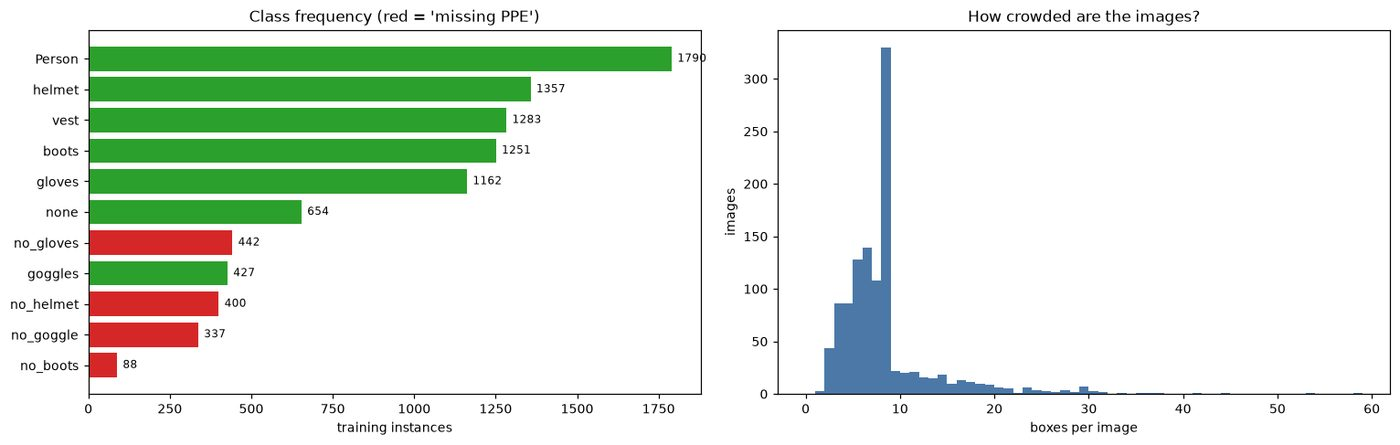

In [6]:
counts, boxes_per_image = Counter(), []
for lbl in (DATA_ROOT / "labels" / "train").glob("*.txt"):
    lines = [l for l in lbl.read_text().strip().splitlines() if l.strip()]
    boxes_per_image.append(len(lines))
    for line in lines:
        counts[int(line.split()[0])] += 1

dist = (pd.DataFrame([(CLASS_NAMES[c], n) for c, n in counts.items()],
                     columns=["class", "instances"])
        .sort_values("instances", ascending=False).reset_index(drop=True))
dist["share_%"] = (dist["instances"] / dist["instances"].sum() * 100).round(2)

print(f"Labelled boxes : {sum(counts.values()):,}")
print(f"Per image      : mean {np.mean(boxes_per_image):.1f}, max {max(boxes_per_image)}")
print(f"Imbalance      : {dist['instances'].max()/dist['instances'].min():.0f}:1\n")
display(dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colors = ["#d62728" if c.startswith("no_") else "#2ca02c" for c in dist["class"]]
axes[0].barh(dist["class"], dist["instances"], color=colors)
axes[0].invert_yaxis(); axes[0].set_xlabel("training instances")
axes[0].set_title("Class frequency (red = 'missing PPE')")
for i, v in enumerate(dist["instances"]):
    axes[0].text(v + max(dist["instances"])*0.01, i, str(v), va="center", fontsize=8)
axes[1].hist(boxes_per_image, bins=range(0, max(boxes_per_image)+2), color="#4C78A8")
axes[1].set_xlabel("boxes per image"); axes[1].set_ylabel("images")
axes[1].set_title("How crowded are the images?")
plt.tight_layout(); plt.show()

> **Read this chart carefully.** The `no_*` classes — a worker *missing* protection — are
> far rarer than the positive classes, and they're exactly what a safety system exists to
> catch. Expect them to score badly. When that shows up in section 10, it isn't a
> training bug; it's this imbalance surfacing.

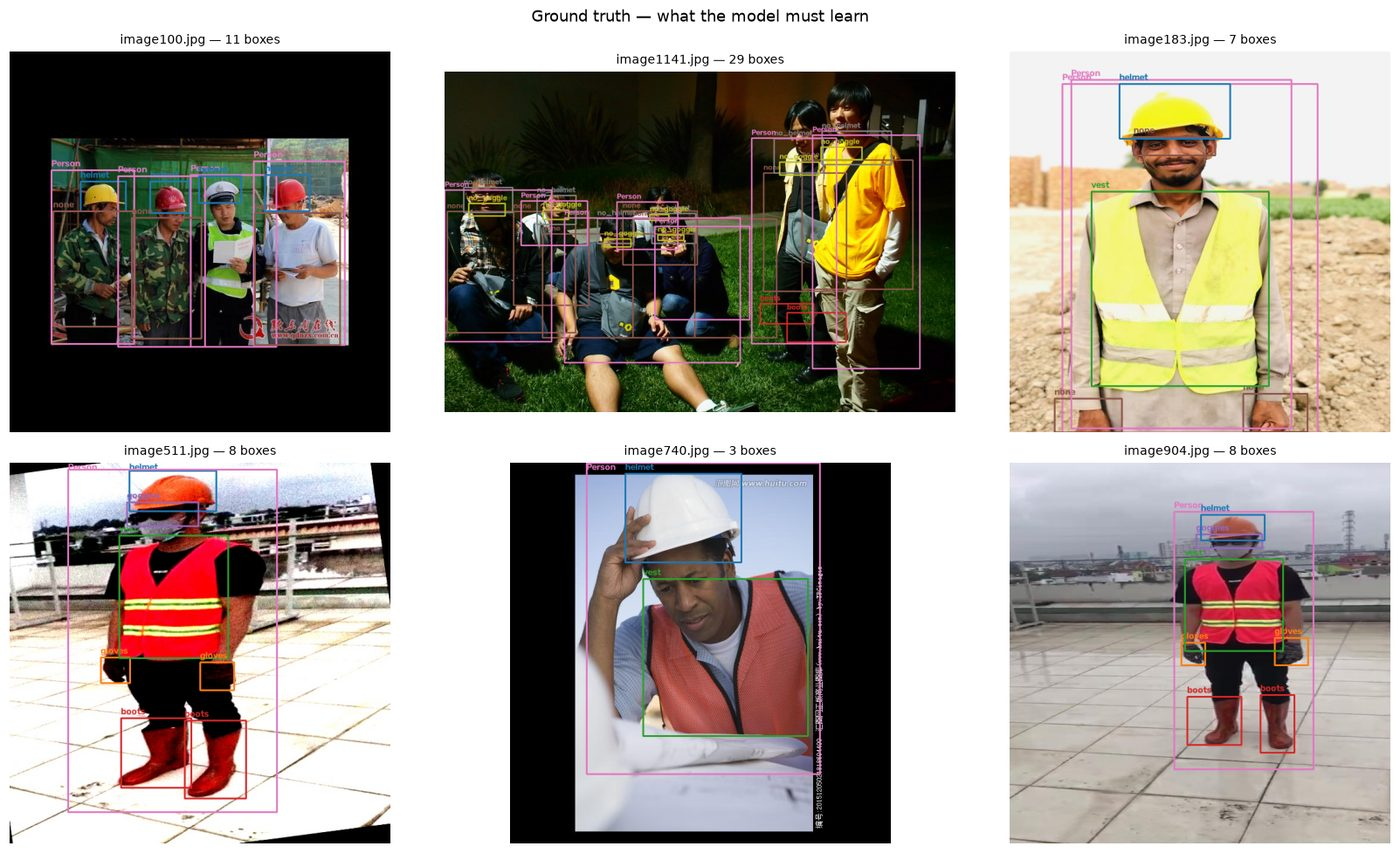

In [7]:
def draw_labels(img_path, label_path):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if not label_path.exists():
        return img
    palette = plt.cm.tab20(np.linspace(0, 1, 11))[:, :3] * 255
    for line in label_path.read_text().strip().splitlines():
        if not line.strip():
            continue
        parts = line.split(); cls = int(parts[0])
        cx, cy, bw, bh = (float(x) for x in parts[1:5])
        x1, y1 = int((cx-bw/2)*w), int((cy-bh/2)*h)
        x2, y2 = int((cx+bw/2)*w), int((cy+bh/2)*h)
        col = tuple(int(c) for c in palette[cls])
        cv2.rectangle(img, (x1, y1), (x2, y2), col, 2)
        cv2.putText(img, CLASS_NAMES[cls], (x1, max(y1-6, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, col, 2)
    return img

train_imgs = sorted(p for p in (DATA_ROOT/"images"/"train").glob("*")
                    if p.suffix.lower() in IMG_EXT)
picks = [train_imgs[i] for i in (0, 120, 400, 700, 900, 1050) if i < len(train_imgs)]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, p in zip(axes.ravel(), picks):
    lbl = DATA_ROOT/"labels"/"train"/f"{p.stem}.txt"
    ax.imshow(draw_labels(p, lbl))
    n = len(lbl.read_text().strip().splitlines()) if lbl.exists() else 0
    ax.set_title(f"{p.name} — {n} boxes", fontsize=9); ax.axis("off")
plt.suptitle("Ground truth — what the model must learn", fontsize=12)
plt.tight_layout(); plt.show()

### About this architecture

YOLO11n pairs a C3k2 backbone with C2PSA attention blocks and a depthwise-separable detection head. Straightforward convolutional inference that is fully covered by Metal and CUDA kernels — which is exactly why it is the dependable baseline for this comparison.

Unlike YOLO26 it has a single one-to-many head, so NMS is always part of inference; there is no NMS-free export path here.

## 7. Training settings — branched on `GPU_AVAILABLE`

The GPU and CPU paths are written out separately rather than hidden behind a clever
expression, so it's obvious what runs where. The CPU path drops to 416 px and caps
epochs at 10, because 59 epochs at 640 px on a CPU is most of a day.

In [8]:
RUN_NAME = "yolo11n"

# ===========================================================================
#  TRAIN = False  ->  skip training and use the weights already committed to
#                     trained_model/. Everything below — validation, test
#                     predictions, speed, live camera — still runs normally.
#                     THIS IS THE DEFAULT. Nothing here needs training.
#
#  TRAIN = True   ->  retrain from the COCO checkpoint in og_model/.
#                     Roughly an hour on a GPU; much longer on CPU.
# ===========================================================================
TRAIN = False
# ===========================================================================

if GPU_AVAILABLE:
    # ---------------- GPU PATH ----------------
    IMGSZ  = 640
    EPOCHS = 59
    if GPU_TYPE == "cuda":
        BATCH   = 32 if GPU_MEM >= 16 else (16 if GPU_MEM >= 8 else 8)
        WORKERS = min(8, os.cpu_count() or 4)
        AMP     = True           # mixed precision is dependable on CUDA
    else:                        # mps
        BATCH   = 16 if (HOST.get('ram_gb') or 16) >= 16 else 8
        WORKERS = 0              # Ultralytics forces 0 on MPS anyway
        AMP     = False          # AMP on MPS is inconsistent across releases
    CACHE       = False
    BENCH_SIZES = (640, 512, 416, 320)
    BENCH_RUNS  = 30
    # Early stopping is normally the right default, but it turns an "N epochs"
    # experiment into "N or fewer", which makes epoch-count comparisons unreadable.
    # For long deliberate runs (>80 epochs) let it go the full distance; best.pt
    # still keeps the peak, so nothing is lost by training past it.
    PATIENCE    = EPOCHS if EPOCHS > 80 else 20
    est = EPOCHS * (50 if GPU_TYPE == "mps" else 25) / 60
    print("GPU PATH")
    print(f"  device   : {DEVICE} ({GPU_TYPE})")
    print(f"  imgsz    : {IMGSZ}")
    print(f"  batch    : {BATCH}")
    print(f"  workers  : {WORKERS}")
    print(f"  amp      : {AMP}")
    print(f"  epochs   : {EPOCHS}")
    print(f"  estimate : ~{est:.0f} min")

else:
    # ---------------- CPU PATH ----------------
    IMGSZ       = 416      # ~2.4x less compute per image than 640
    EPOCHS      = 10
    BATCH       = 4
    WORKERS     = 0
    AMP         = False
    CACHE       = "ram" if (HOST.get("ram_gb") or 8) >= 16 else False
    BENCH_SIZES = (416, 320)
    BENCH_RUNS  = 8
    PATIENCE    = 5
    print("!" * 68)
    print("  CPU PATH — no GPU detected")
    print("!" * 68)
    print(f"  device   : cpu")
    print(f"  imgsz    : {IMGSZ}   (reduced from 640)")
    print(f"  batch    : {BATCH}")
    print(f"  epochs   : {EPOCHS}  (capped from 59)")
    print(f"  cache    : {CACHE}")
    print()
    print("  Expect roughly 10-20 min per epoch, so ~2-3 hours total.")
    print("  For a quick check that everything works, set EPOCHS = 1 and re-run")
    print("  this cell before training.")

print()
print(f"Loading base weights from: {OG_WEIGHTS}")
MODEL_CLS = YOLO
model = MODEL_CLS(str(OG_WEIGHTS))   # explicit path -> never triggers a download
n_params = sum(p.numel() for p in model.model.parameters())
print(f"  {MODEL_NAME}: {n_params:,} parameters ({n_params/1e6:.2f} M)")

GPU PATH
  device   : mps (mps)
  imgsz    : 640
  batch    : 16
  workers  : 0
  amp      : False
  epochs   : 59
  estimate : ~49 min

Loading base weights from: /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/og_model/yolo11n.pt
  yolo11n.pt: 2,624,080 parameters (2.62 M)


## 8. Live progress reporter

Ultralytics repaints its progress bars with the ANSI erase-line sequence. That looks
fine in a terminal, but a saved notebook keeps every frame, so one epoch becomes
hundreds of near-identical lines.

This prints one clean line per epoch instead — visible live *and* readable afterwards —
and raises the Ultralytics log level to silence the bars. The whole thing is wrapped in
`try/except`: a cosmetic print must never be able to abort a multi-hour training run.

In [9]:
epoch_times, _prev_level = [], [None]
guard  = {"t0": None, "baseline": None, "cooldowns": 0, "paused": 0.0}
best_so_far = {"map": -1.0, "epoch": 0}
train_t0 = [None]

# Thermal guard. macOS exposes no temperature without root, so throttling is
# inferred from its symptom: identical work starting to take longer.
SLOWDOWN_FACTOR = 1.35
COOLDOWN_S      = 45 if GPU_AVAILABLE else 0   # CPU runs are slow but cool

def _eta(sec):
    sec = int(max(sec, 0)); h, rem = divmod(sec, 3600); m, s = divmod(rem, 60)
    return f"{h}h{m:02d}m" if h else f"{m}m{s:02d}s"

def on_train_start(trainer):
    train_t0[0] = time.monotonic()
    _prev_level[0] = LOGGER.getEffectiveLevel()
    LOGGER.setLevel(logging.WARNING)      # disable = ... or level > 20
    print(f"\nTraining {RUN_NAME}: {trainer.epochs} epochs on {DEVICE} "
          f"(imgsz {IMGSZ}, batch {BATCH})")
    print("=" * 108)
    print(f"{'epoch':>7} {'box':>7} {'cls':>7} | {'P':>6} {'R':>6} "
          f"{'mAP50':>7} {'mAP50-95':>9} | {'sec':>6} {'elapsed':>8} {'eta':>8}")
    print("=" * 108, flush=True)

def on_epoch_start(trainer):
    guard["t0"] = time.monotonic()

def _report(trainer):
    dt = time.monotonic() - (guard["t0"] or time.monotonic())
    epoch_times.append(dt)
    total = trainer.epochs
    e = min(trainer.epoch + 1, total)
    if len(epoch_times) > total:      # the extra final-validation call
        return

    m = trainer.metrics or {}
    p_  = m.get("metrics/precision(B)", float("nan"))
    r_  = m.get("metrics/recall(B)", float("nan"))
    m50 = m.get("metrics/mAP50(B)", float("nan"))
    m95 = m.get("metrics/mAP50-95(B)", float("nan"))

    # trainer.loss_items is a DICT keyed by loss name, not a sequence.
    # Indexing it with [0] raises KeyError and kills the run from inside the callback.
    box = cls = float("nan")
    li = getattr(trainer, "loss_items", None)
    if isinstance(li, dict):
        v = {k.replace("_loss", ""): float(x) for k, x in li.items()}
        box, cls = v.get("box", box), v.get("cls", cls)

    elapsed = time.monotonic() - (train_t0[0] or time.monotonic())
    star = ""
    if m95 == m95 and m95 > best_so_far["map"]:
        best_so_far.update({"map": m95, "epoch": e}); star = "  <-- best"

    print(f"{e:>3}/{total:<3} {box:>7.3f} {cls:>7.3f} | {p_:>6.3f} {r_:>6.3f} "
          f"{m50:>7.4f} {m95:>9.4f} | {dt:>6.1f} {_eta(elapsed):>8} "
          f"{_eta((elapsed/e)*(total-e)):>8}{star}", flush=True)

    n = len(epoch_times)
    if n < 2 or not COOLDOWN_S:
        return
    if guard["baseline"] is None and n >= 4:
        guard["baseline"] = float(np.median(epoch_times[1:]))
        print(f"        [guard] baseline {guard['baseline']:.0f}s/epoch", flush=True)
    elif guard["baseline"] and dt / guard["baseline"] >= SLOWDOWN_FACTOR:
        guard["cooldowns"] += 1
        print(f"        [guard] {dt/guard['baseline']:.2f}x baseline — cooling "
              f"{COOLDOWN_S}s", flush=True)
        time.sleep(COOLDOWN_S); guard["paused"] += COOLDOWN_S

def on_fit_epoch_end(trainer):
    try:
        _report(trainer)
    except Exception as err:
        print(f"   [reporter] {type(err).__name__}: {err}", flush=True)

def on_train_end(trainer):
    LOGGER.setLevel(_prev_level[0] or logging.INFO)
    print("=" * 108)
    print(f"Best mAP50-95 {best_so_far['map']:.4f} at epoch {best_so_far['epoch']}")

for ev, fn in [("on_train_start", on_train_start),
               ("on_train_epoch_start", on_epoch_start),
               ("on_fit_epoch_end", on_fit_epoch_end),
               ("on_train_end", on_train_end)]:
    model.add_callback(ev, fn)

print("Live reporter attached — one line per epoch, with running ETA.")

Live reporter attached — one line per epoch, with running ETA.


## 9. Train

`optimizer="auto"` rather than a hand-set AdamW + `lr0=0.01`. That pairing circulates
widely and is about ten times too hot for AdamW — it plateaus or diverges. Auto mode
picks the optimizer *and* learning rate from the dataset size; the log reports its
choice, and you'll see it explicitly say it's ignoring `lr0=0.01`.

Watch the table below fill in, one row per epoch.

In [10]:
t_start = time.time()
TRAINED_DIR = PROJECT / "trained_model"
LOGS_DIR    = PROJECT / "training_logs"

def results_csv():
    # The per-epoch log, whether this session trained or not. With TRAIN = False
    # there is no fresh run to read, so fall back to the log committed in
    # training_logs/ — that is what lets the curve and epoch-table cells below
    # work without anyone having to retrain.
    for cand in (SAVE_DIR / "results.csv", LOGS_DIR / f"{RUN_NAME}_results.csv"):
        if cand.exists():
            return cand
    return None

if not TRAIN:
    # ---------------- inference mode (the default) -------------------------
    # Use the weights committed to the repository. No training happens, and no
    # cell below depends on this one having trained anything.
    BEST = TRAINED_DIR / f"{RUN_NAME}_best.pt"
    if not BEST.exists():
        raise FileNotFoundError(
            f"\n{'='*70}\n"
            f"  Trained weights not found:\n    {BEST}\n\n"
            f"  Either re-clone the repository (the weights are committed there),\n"
            f"  or set TRAIN = True in the cell above to train them yourself.\n"
            f"{'='*70}")
    SAVE_DIR = RUNS_DIR / RUN_NAME
    elapsed  = 0.0
    print("TRAIN = False  ->  using the committed weights. No training run.")
    print(f"  weights : {BEST}")
    print(f"  size    : {BEST.stat().st_size/1024**2:.2f} MB")
    print(f"\n  Set TRAIN = True above if you want to retrain from scratch.")

else:
    results = model.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        optimizer="auto",
        amp=AMP,
        cache=CACHE,
        patience=PATIENCE,
        close_mosaic=10 if EPOCHS > 15 else 0,
        seed=0,
        # MPS has no deterministic index_put_ kernel, so this cannot be
        # honoured there and only produces a warning per epoch.
        deterministic=GPU_AVAILABLE and GPU_TYPE == "cuda",
        plots=True,
        save=True,
        project=str(RUNS_DIR),  # absolute: a relative value goes to ~/runs
        name=RUN_NAME,
        exist_ok=True,
        verbose=False,          # our reporter prints the epochs instead
    )

    elapsed  = time.time() - t_start
    SAVE_DIR = Path(results.save_dir)
    BEST     = SAVE_DIR / "weights" / "best.pt"
    if not BEST.exists():
        BEST = SAVE_DIR / "weights" / "last.pt"

    print(f"\n{'='*68}")
    print(f"  Finished in {elapsed/60:.1f} min "
          f"({elapsed/max(len(epoch_times),1):.0f}s per epoch on {DEVICE})")
    print(f"  Weights: {BEST}  ({BEST.stat().st_size/1024**2:.2f} MB)")
    print(f"{'='*68}")

TRAIN = False  ->  using the committed weights. No training run.
  weights : /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/trained_model/yolo11n_best.pt
  size    : 5.22 MB

  Set TRAIN = True above if you want to retrain from scratch.


## 10. Save the trained weights to `trained_model/`

In [11]:
# Recovery: if the training cell was skipped or interrupted, pick up the most
# recent run from disk so the rest of the notebook still works.
if TRAIN and ("SAVE_DIR" not in dir() or not Path(SAVE_DIR).exists()):
    prev = sorted([d for d in RUNS_DIR.glob(f"{RUN_NAME}*") if (d/"results.csv").exists()],
                  key=lambda d: d.stat().st_mtime)
    if not prev:
        raise RuntimeError(f"No run found in {RUNS_DIR}. Run the training cell first.")
    SAVE_DIR = prev[-1]
    BEST = SAVE_DIR/"weights"/"best.pt"
    if not BEST.exists():
        BEST = SAVE_DIR/"weights"/"last.pt"
    elapsed = elapsed if "elapsed" in dir() else 0.0
    print(f"Recovered previous run: {SAVE_DIR}")

saved = {}
if not TRAIN:
    for kind in ("best", "last"):
        dst = TRAINED_DIR / f"{RUN_NAME}_{kind}.pt"
        if dst.exists():
            saved[kind] = str(dst)
            print(f"  {kind:<5} already in trained_model/  "
                  f"({dst.stat().st_size/1024**2:.2f} MB)")
    print("\n(TRAIN = False, so nothing was retrained and nothing was overwritten.)")

for kind in ("best", "last") if TRAIN else ():
    src = SAVE_DIR / "weights" / f"{kind}.pt"
    if src.exists():
        dst = TRAINED_DIR / f"{RUN_NAME}_{kind}.pt"
        shutil.copy2(src, dst)
        saved[kind] = str(dst)
        print(f"  {kind:<5} -> {dst}   ({dst.stat().st_size/1024**2:.2f} MB)")

print(f"\nog_model/      : {MODEL_NAME} (pretrained, untouched)")
print(f"trained_model/ : {', '.join(Path(v).name for v in saved.values())}")

  best  already in trained_model/  (5.22 MB)
  last  already in trained_model/  (5.22 MB)

(TRAIN = False, so nothing was retrained and nothing was overwritten.)

og_model/      : yolo11n.pt (pretrained, untouched)
trained_model/ : yolo11n_best.pt, yolo11n_last.pt


## 11. Every epoch, in full

In [12]:
_csv = results_csv()
if _csv is None:
    raise FileNotFoundError(
        f"No epoch log found. Expected either {SAVE_DIR/'results.csv'} or "
        f"{LOGS_DIR/(RUN_NAME + '_results.csv')}.")
print(f"reading epoch log: {_csv.relative_to(PROJECT)}\n")
hist = pd.read_csv(_csv)
hist.columns = [c.strip() for c in hist.columns]

table = pd.DataFrame({
    "epoch":    hist["epoch"].astype(int),
    "box_loss": hist["train/box_loss"].round(4),
    "cls_loss": hist["train/cls_loss"].round(4),
    "val_box":  hist["val/box_loss"].round(4),
    "val_cls":  hist["val/cls_loss"].round(4),
    "P":        hist["metrics/precision(B)"].round(4),
    "R":        hist["metrics/recall(B)"].round(4),
    "mAP50":    hist["metrics/mAP50(B)"].round(4),
    "mAP50-95": hist["metrics/mAP50-95(B)"].round(4),
})
best_ep = int(hist.loc[hist["metrics/mAP50-95(B)"].idxmax(), "epoch"])
table["best"] = ["  <-- best" if e == best_ep else "" for e in table["epoch"]]

print(f"All {len(table)} epochs (best mAP50-95 at epoch {best_ep})")
print("=" * 100)
print(table.to_string(index=False))
print("=" * 100)

reading epoch log: runs/yolo11n/results.csv

All 59 epochs (best mAP50-95 at epoch 57)
 epoch  box_loss  cls_loss  val_box  val_cls      P      R  mAP50  mAP50-95       best
     1    1.8727    3.4400   1.8919   3.5438 0.1345 0.3004 0.2192    0.1016
     2    1.8360    2.2070   2.0456   2.3512 0.7799 0.3250 0.3456    0.1632
     3    1.8504    1.8683   2.0611   2.0253 0.6926 0.4257 0.4178    0.1744
     4    1.7812    1.7178   1.9361   1.9326 0.7238 0.3939 0.4273    0.1997
     5    1.7757    1.6444   2.0155   1.8896 0.5233 0.4043 0.4111    0.1894
     6    1.7462    1.5955   1.9180   1.7678 0.8114 0.3927 0.4555    0.2080
     7    1.7116    1.5446   1.8745   1.6929 0.7312 0.4440 0.4768    0.2215
     8    1.7131    1.5048   1.8489   1.6063 0.6509 0.4566 0.4938    0.2299
     9    1.6809    1.4406   1.8613   1.6080 0.6195 0.4622 0.4920    0.2307
    10    1.6738    1.3948   1.9453   1.6277 0.5628 0.4582 0.4633    0.2160
    11    1.6689    1.3872   1.8327   1.4805 0.7200 0.4651 0.5087 

---

## 12. Validation

**This section and everything after it runs on its own.** It needs only the trained
weights in `trained_model/` and the dataset — no training, and no dependency on the
cells above having been run.

The cell below rebuilds the handful of names the later cells use. Run it after a kernel
restart, or if you jumped straight here, and the rest of the notebook will work. It is
harmless to run when the earlier cells already executed: anything already defined is
left untouched.

In [13]:
# ---- makes this section self-contained ------------------------------------
# setdefault, not assignment: if the cells above already ran, their values win.
import ppe_lib as ppe
for _k, _v in ppe.bootstrap(RUN_NAME if "RUN_NAME" in dir() else "yolo11n").items():
    globals().setdefault(_k, _v)

Section context rebuilt for 'yolo11n':
  weights   : yolo11n_best.pt  (5.22 MB)
  device    : MPS
  imgsz     : 640
  epoch log : results.csv
  train class counts loaded: 9191 boxes


In [14]:
best_model = MODEL_CLS(BEST)

if GPU_AVAILABLE:
    metrics = best_model.val(data=str(DATA_YAML), imgsz=IMGSZ, batch=BATCH,
                             device=DEVICE, workers=WORKERS, split="val", plots=True,
                             project=str(RUNS_DIR), name=f"{RUN_NAME}_val",
                             exist_ok=True, verbose=False)
else:
    # Smaller batch keeps CPU memory flat; plots still produced.
    metrics = best_model.val(data=str(DATA_YAML), imgsz=IMGSZ, batch=2,
                             device="cpu", workers=0, split="val", plots=True,
                             project=str(RUNS_DIR), name=f"{RUN_NAME}_val",
                             exist_ok=True, verbose=False)

summary = {"mAP50": float(metrics.box.map50), "mAP50-95": float(metrics.box.map),
           "precision": float(metrics.box.mp), "recall": float(metrics.box.mr)}

print("Validation (143 held-out images)")
print("-" * 46)
for k, v in summary.items():
    print(f"  {k:<11} {v:.4f}")
print()
print(f"  Precision {summary['precision']:.2f} -> of what it flags, "
      f"{summary['precision']*100:.0f}% is really there")
print(f"  Recall    {summary['recall']:.2f} -> of what is there, "
      f"it finds {summary['recall']*100:.0f}%")

Ultralytics 8.4.163 🚀 Python-3.14.4 torch-2.14.0 MPS (Apple M2 Pro)
YOLO11n summary (fused): 100 layers, 2,584,297 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 626.4±919.7 MB/s, size: 209.5 KB)
val: Scanning /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/dataset/construction-ppe/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 37.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 3.9it/s 2.3s
                   all        143       1172      0.703      0.523       0.57      0.284
Speed: 0.2ms preprocess, 5.6ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/runs/yolo11n_val
Validation (143 held-out images)
----------------------------------------------
  mAP50       0.5704
  mAP50-95    0.2841
  precision   0.7028
  recall      0.52

,class,precision,recall,mAP50,mAP50-95,train_instances
0,vest,0.8144,0.7953,0.8550,0.5154,1283
1,Person,0.8316,0.8870,0.8931,0.5112,1790
2,boots,0.7966,0.7219,0.7807,0.4541,1251
3,helmet,0.8274,0.8347,0.8310,0.4470,1357
4,goggles,0.8395,0.7660,0.8129,0.4011,427
5,gloves,0.8211,0.7426,0.8105,0.3882,1162
6,none,0.5280,0.5432,0.4564,0.1729,654
7,no_helmet,0.5719,0.3333,0.3987,0.1267,400
8,no_gloves,0.6396,0.1250,0.2446,0.0606,442
9,no_goggle,0.0610,0.0074,0.1247,0.0366,337


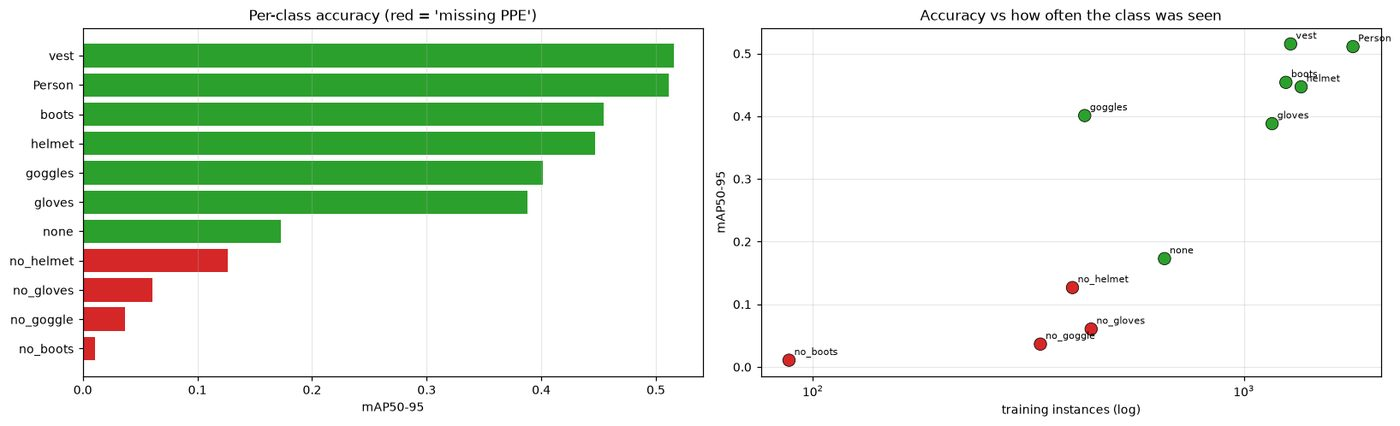

In [15]:
idx = list(metrics.box.ap_class_index)
per_class = pd.DataFrame([{
    "class": CLASS_NAMES[int(c)],
    "precision": float(metrics.box.p[i]), "recall": float(metrics.box.r[i]),
    "mAP50": float(metrics.box.ap50[i]),  "mAP50-95": float(metrics.box.ap[i]),
    "train_instances": counts.get(int(c), 0),
} for i, c in enumerate(idx)]).sort_values("mAP50-95", ascending=False).reset_index(drop=True)

display(per_class.style
        .format({c: "{:.4f}" for c in ["precision","recall","mAP50","mAP50-95"]})
        .background_gradient(cmap="RdYlGn", subset=["mAP50-95"], vmin=0, vmax=0.6))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
cols = ["#d62728" if c.startswith("no_") else "#2ca02c" for c in per_class["class"]]
axes[0].barh(per_class["class"], per_class["mAP50-95"], color=cols)
axes[0].invert_yaxis(); axes[0].set_xlabel("mAP50-95")
axes[0].set_title("Per-class accuracy (red = 'missing PPE')"); axes[0].grid(axis="x", alpha=.3)
axes[1].scatter(per_class["train_instances"], per_class["mAP50-95"], c=cols, s=90,
                edgecolors="black", linewidths=.5, zorder=3)
for _, r in per_class.iterrows():
    axes[1].annotate(r["class"], (r["train_instances"], r["mAP50-95"]),
                     fontsize=7.5, xytext=(4,4), textcoords="offset points")
axes[1].set_xscale("symlog"); axes[1].set_xlabel("training instances (log)")
axes[1].set_ylabel("mAP50-95"); axes[1].set_title("Accuracy vs how often the class was seen")
axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

> The right-hand plot is the explanation for everything weak in the left-hand one:
> accuracy tracks training frequency almost monotonically. That means more epochs won't
> rescue the `no_*` classes — it's a data problem, not a training one.
>
> What would actually work: merge `no_helmet`/`no_vest`/`no_gloves`/`no_boots`/`no_goggle`
> into a single `missing_ppe` class (pools the scarce examples, and "this person is
> non-compliant" is usually the real requirement anyway), oversample those images, or
> collect more of them.

## 13. Predictions — original beside model output

In [16]:
TEST_DIR = DATA_ROOT / "images" / "test"
PRED_DIR = PRED_ROOT / RUN_NAME
PRED_DIR.mkdir(parents=True, exist_ok=True)
test_images = sorted(p for p in TEST_DIR.glob("*") if p.suffix.lower() in IMG_EXT)

if GPU_AVAILABLE:
    preds = best_model.predict(source=str(TEST_DIR), imgsz=IMGSZ, device=DEVICE,
                               conf=0.25, iou=0.45, save=True, save_txt=True,
                               save_conf=True, project=str(PRED_ROOT), name=RUN_NAME,
                               exist_ok=True, verbose=False)
else:
    # On CPU, predicting 141 images one at a time keeps memory flat and lets you
    # see progress rather than waiting on one long silent call.
    print(f"CPU mode — predicting {len(test_images)} images (a few minutes)...")
    preds = []
    for i, img in enumerate(test_images, 1):
        preds += best_model.predict(source=str(img), imgsz=IMGSZ, device="cpu",
                                    conf=0.25, iou=0.45, save=True, save_txt=True,
                                    save_conf=True, project=str(PRED_ROOT),
                                    name=RUN_NAME, exist_ok=True, verbose=False)
        if i % 25 == 0:
            print(f"  {i}/{len(test_images)}", flush=True)

total_boxes = sum(len(r.boxes) for r in preds)
empty = sum(1 for r in preds if len(r.boxes) == 0)
print(f"\nImages          : {len(preds)}")
print(f"Detections      : {total_boxes}  ({total_boxes/max(len(preds),1):.1f} per image)")
print(f"Images with none: {empty}")
print(f"Saved to        : {PRED_DIR}")

Results saved to /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/predictions/yolo11n
141 labels saved to /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/predictions/yolo11n/labels

Images          : 141
Detections      : 1087  (7.7 per image)
Images with none: 0
Saved to        : /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/predictions/yolo11n


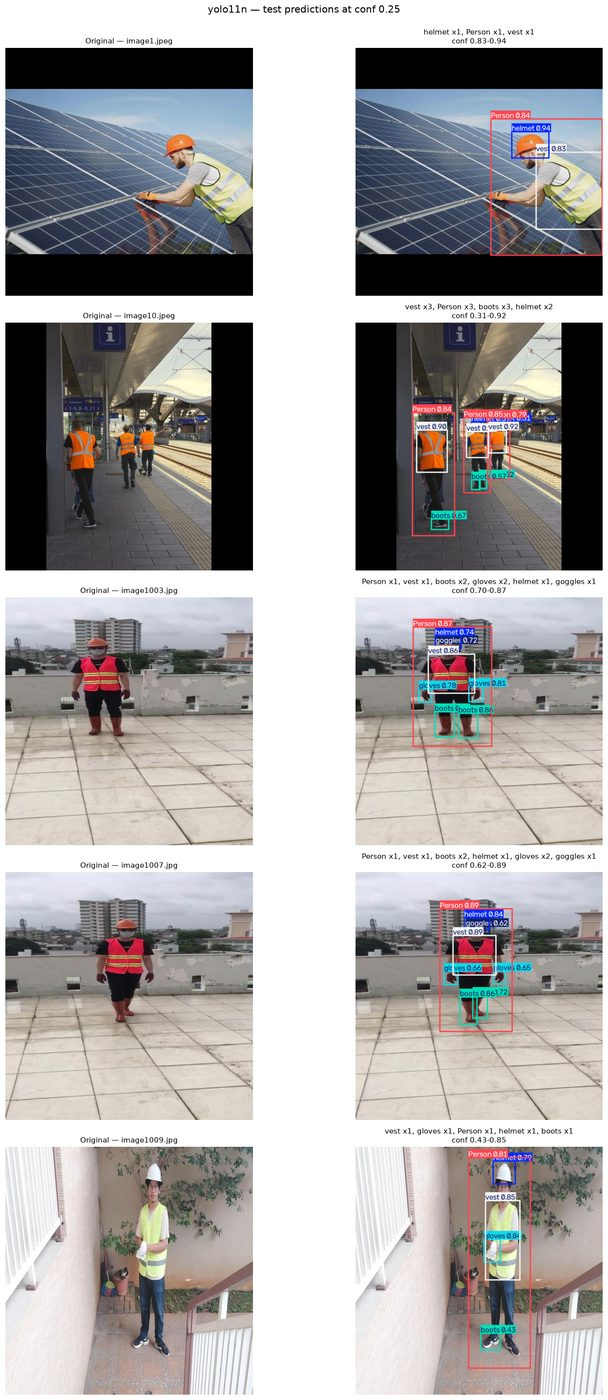

In [17]:
show = preds[:5]
fig, axes = plt.subplots(len(show), 2, figsize=(15, 5.2*len(show)))
if len(show) == 1:
    axes = np.array([axes])
for row, r in zip(axes, show):
    row[0].imshow(cv2.cvtColor(cv2.imread(r.path), cv2.COLOR_BGR2RGB))
    row[0].set_title(f"Original — {Path(r.path).name}", fontsize=10); row[0].axis("off")
    row[1].imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    if len(r.boxes):
        found = Counter(CLASS_NAMES[int(c)] for c in r.boxes.cls.tolist())
        t = ", ".join(f"{k} x{v}" for k, v in found.items())
        t += chr(10) + f"conf {r.boxes.conf.min():.2f}-{r.boxes.conf.max():.2f}"
    else:
        t = "nothing detected"
    row[1].set_title(t, fontsize=10); row[1].axis("off")
plt.suptitle(f"{RUN_NAME} — test predictions at conf 0.25", fontsize=13, y=0.999)
plt.tight_layout(); plt.show()

Median confidence: 0.787


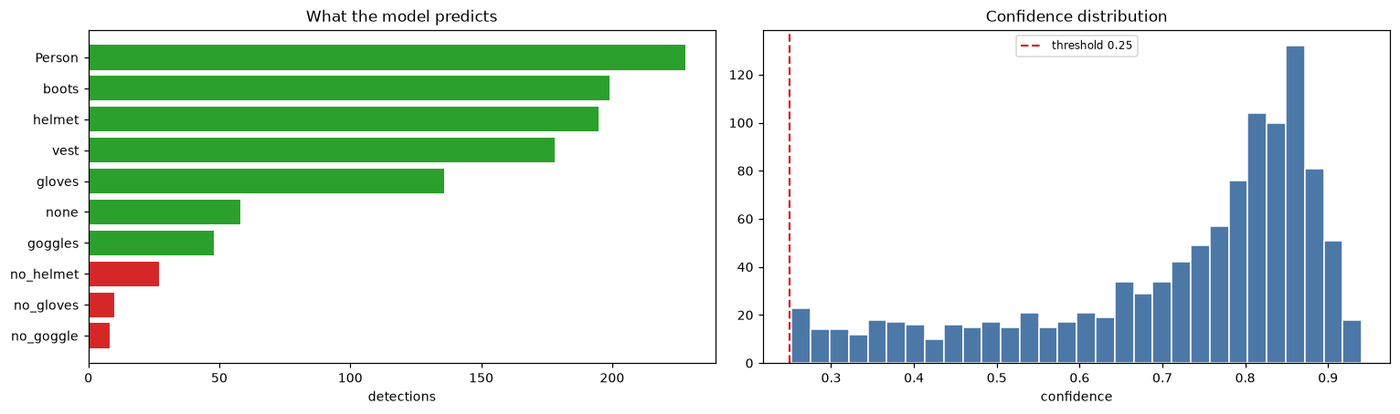

,class,detections
0,Person,228
1,boots,199
2,helmet,195
3,vest,178
4,gloves,136
5,none,58
6,goggles,48
7,no_helmet,27
8,no_gloves,10
9,no_goggle,8


In [18]:
pred_counts, confs = Counter(), []
for r in preds:
    for c, cf in zip(r.boxes.cls.tolist(), r.boxes.conf.tolist()):
        pred_counts[CLASS_NAMES[int(c)]] += 1; confs.append(cf)

pdist = (pd.DataFrame(pred_counts.items(), columns=["class","detections"])
         .sort_values("detections", ascending=False).reset_index(drop=True))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
cols = ["#d62728" if c.startswith("no_") else "#2ca02c" for c in pdist["class"]]
axes[0].barh(pdist["class"], pdist["detections"], color=cols); axes[0].invert_yaxis()
axes[0].set_xlabel("detections"); axes[0].set_title("What the model predicts")
axes[1].hist(confs, bins=30, color="#4C78A8", edgecolor="white")
axes[1].axvline(0.25, ls="--", c="#d62728", label="threshold 0.25")
axes[1].set_xlabel("confidence"); axes[1].set_title("Confidence distribution")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pdist)
print(f"Median confidence: {np.median(confs):.3f}")

## 14. Speed — is it fast enough for live video?

  640px     9.98 ms     100.2 FPS
  512px     9.94 ms     100.6 FPS
  416px     8.66 ms     115.4 FPS
  320px     9.25 ms     108.2 FPS
At 640px: 100.2 FPS on mps (3.3x the 30 FPS bar)


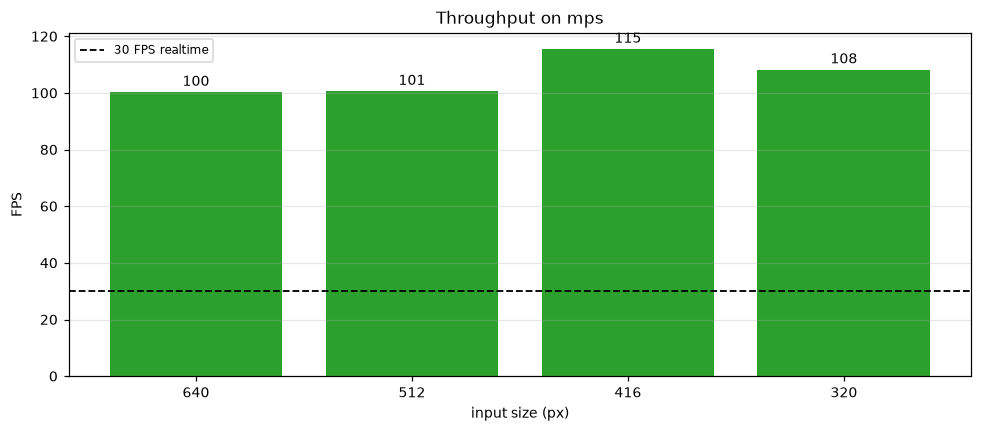

In [19]:
def measure(m, images, imgsz, warmup=3, runs=None):
    runs = runs or BENCH_RUNS
    for i in range(warmup):
        m.predict(images[i % len(images)], imgsz=imgsz, device=DEVICE, verbose=False)
    if GPU_AVAILABLE:
        torch.cuda.synchronize() if GPU_TYPE == "cuda" else torch.mps.synchronize()
    times = []
    for i in range(runs):
        t0 = time.perf_counter()
        m.predict(images[i % len(images)], imgsz=imgsz, device=DEVICE, verbose=False)
        if GPU_AVAILABLE:
            torch.cuda.synchronize() if GPU_TYPE == "cuda" else torch.mps.synchronize()
        times.append((time.perf_counter()-t0)*1000)
    return times

sample = [str(p) for p in test_images[:10]]
bench = {}
for size in BENCH_SIZES:
    t = measure(best_model, sample, size)
    bench[size] = {"mean_ms": float(np.mean(t)), "median_ms": float(np.median(t)),
                   "p90_ms": float(np.percentile(t, 90)), "fps": 1000/float(np.mean(t))}
    print(f"  {size:>3}px  {np.mean(t):7.2f} ms   {1000/np.mean(t):7.1f} FPS")

ref = max(bench)
fig, ax = plt.subplots(figsize=(9, 4))
sizes = list(bench); fps = [bench[s]["fps"] for s in sizes]
bars = ax.bar([str(s) for s in sizes], fps,
              color=["#2ca02c" if f >= 30 else "#d62728" for f in fps])
ax.axhline(30, ls="--", c="black", lw=1.2, label="30 FPS realtime")
for b, f in zip(bars, fps):
    ax.text(b.get_x()+b.get_width()/2, f+max(fps)*0.02, f"{f:.0f}", ha="center", fontsize=9)
ax.set_xlabel("input size (px)"); ax.set_ylabel("FPS")
ax.set_title(f"Throughput on {DEVICE}"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

print(f"At {ref}px: {bench[ref]['fps']:.1f} FPS on {DEVICE} "
      f"({bench[ref]['fps']/30:.1f}x the 30 FPS bar)")
if not GPU_AVAILABLE:
    print("Note: this is CPU inference. The same weights on a GPU run far faster.")

## 15. Export

In [20]:
import importlib.util
spec = importlib.util.find_spec("coremltools")
can_coreml = bool(spec and spec.submodule_search_locations and
                  list(Path(list(spec.submodule_search_locations)[0]).glob("libmilstoragepython*.so")))

exports = {}
formats = [("onnx", dict(opset=13, simplify=True)), ("torchscript", {})]
if can_coreml and platform.system() == "Darwin":
    formats.insert(0, ("coreml", dict(half=True, nms=True)))
elif platform.system() == "Darwin":
    print(f"CoreML skipped — coremltools has no native extension for Python "
          f"{sys.version_info.major}.{sys.version_info.minor}. "
          f"Use scripts/export_coreml.py under Python 3.11-3.13.\n")

for fmt, kw in formats:
    try:
        p = Path(best_model.export(format=fmt, imgsz=IMGSZ, **kw))
        dst = EXPORT_DIR / f"{RUN_NAME}_{p.name}"
        if p.is_dir():
            shutil.rmtree(dst, ignore_errors=True); shutil.copytree(p, dst)
        else:
            shutil.copy2(p, dst)
        exports[fmt] = {"path": str(dst), "size_mb": round(
            (sum(f.stat().st_size for f in dst.rglob('*') if f.is_file())
             if dst.is_dir() else dst.stat().st_size)/1024**2, 2)}
    except Exception as e:
        exports[fmt] = {"error": str(e)[:160]}
        print(f"  {fmt} export failed: {str(e)[:160]}")

print("\nArtifacts")
print("-" * 62)
print(f"  {'trained .pt':<16} {BEST.stat().st_size/1024**2:>7.2f} MB")
for k, v in exports.items():
    if "size_mb" in v:
        print(f"  {k:<16} {v['size_mb']:>7.2f} MB   {v['path']}")
    else:
        print(f"  {k:<16} {'—':>7}      {v['error'][:60]}")

CoreML skipped — coremltools has no native extension for Python 3.14. Use scripts/export_coreml.py under Python 3.11-3.13.

Ultralytics 8.4.163 🚀 Python-3.14.4 torch-2.14.0 CPU (Apple M2 Pro)
YOLO11n summary (fused): 100 layers, 2,584,297 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/trained_model/yolo11n_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 15, 8400) (5.2 MB)

ONNX: starting export with onnx 1.23.0 opset 13...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 0.7s, saved as '/Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/trained_model/yolo11n_best.onnx' (10.1 MB)

Export complete (0.9s)
Results saved to /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/trained_model/yolo11n_best.onnx
Predict:         yolo predict task=detect model=/Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/trained_model/yolo11n

---

# 16. Final recap

Curves and predictions collected here so the run can be read without scrolling back.

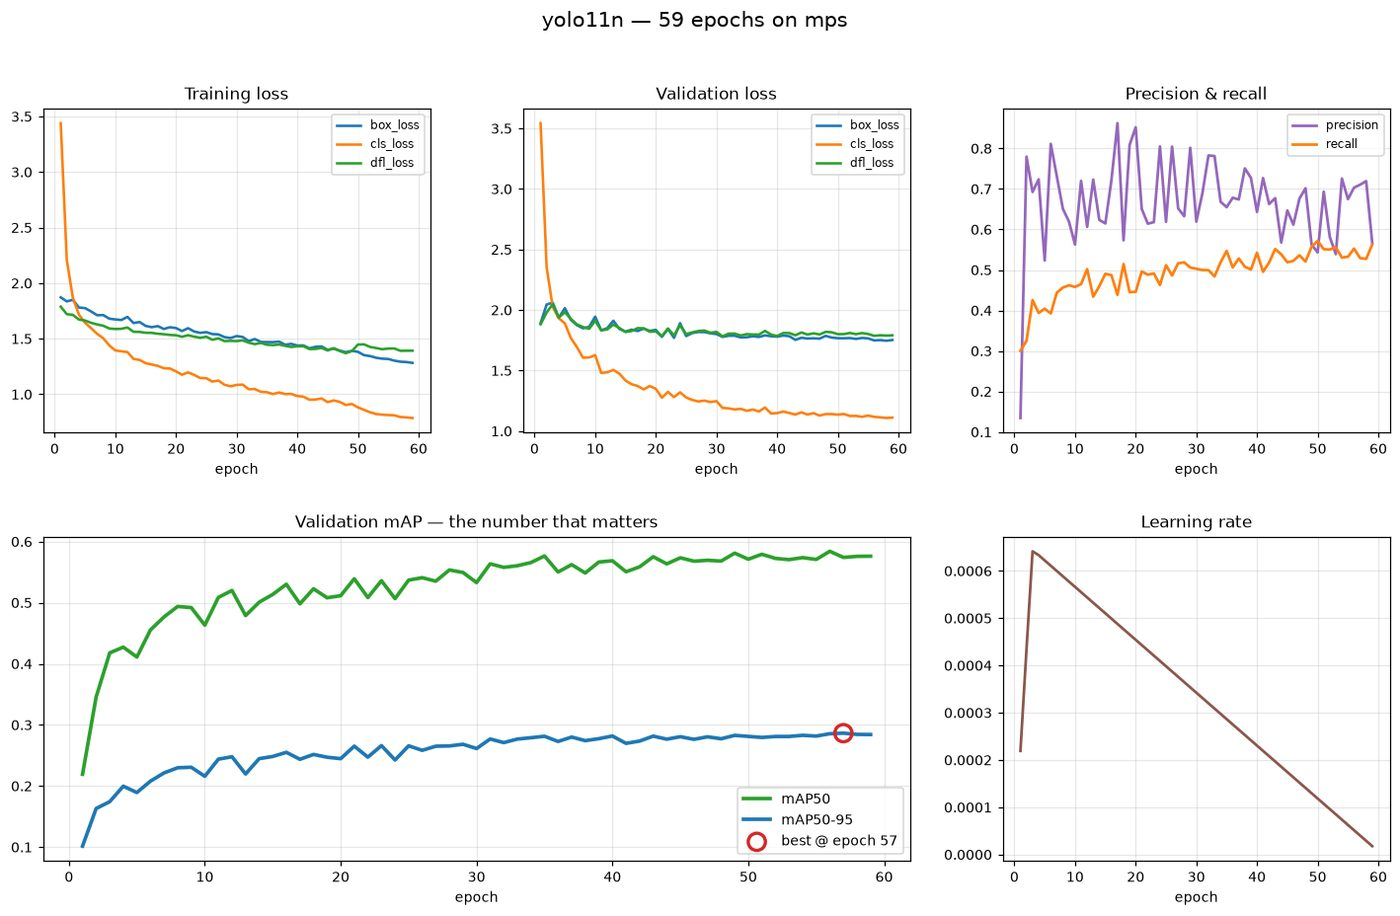

In [21]:
hist = pd.read_csv(results_csv())
hist.columns = [c.strip() for c in hist.columns]

fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 3, hspace=0.32, wspace=0.24)

ax = fig.add_subplot(gs[0, 0])
for c in [c for c in hist.columns if c.startswith("train/")]:
    ax.plot(hist["epoch"], hist[c], lw=1.7, label=c.replace("train/",""))
ax.set_title("Training loss"); ax.set_xlabel("epoch"); ax.legend(fontsize=8); ax.grid(alpha=.3)

ax = fig.add_subplot(gs[0, 1])
for c in [c for c in hist.columns if c.startswith("val/")]:
    ax.plot(hist["epoch"], hist[c], lw=1.7, label=c.replace("val/",""))
ax.set_title("Validation loss"); ax.set_xlabel("epoch"); ax.legend(fontsize=8); ax.grid(alpha=.3)

ax = fig.add_subplot(gs[0, 2])
ax.plot(hist["epoch"], hist["metrics/precision(B)"], lw=1.8, color="#9467bd", label="precision")
ax.plot(hist["epoch"], hist["metrics/recall(B)"], lw=1.8, color="#ff7f0e", label="recall")
ax.set_title("Precision & recall"); ax.set_xlabel("epoch"); ax.legend(fontsize=8); ax.grid(alpha=.3)

ax = fig.add_subplot(gs[1, :2])
ax.plot(hist["epoch"], hist["metrics/mAP50(B)"], lw=2.4, color="#2ca02c", label="mAP50")
ax.plot(hist["epoch"], hist["metrics/mAP50-95(B)"], lw=2.4, color="#1f77b4", label="mAP50-95")
pk = hist["metrics/mAP50-95(B)"].idxmax()
ax.scatter(hist.loc[pk,"epoch"], hist.loc[pk,"metrics/mAP50-95(B)"], s=130,
           facecolors="none", edgecolors="#d62728", linewidths=2.2, zorder=5,
           label=f"best @ epoch {int(hist.loc[pk,'epoch'])}")
ax.set_title("Validation mAP — the number that matters", fontsize=11)
ax.set_xlabel("epoch"); ax.legend(fontsize=9); ax.grid(alpha=.3)

ax = fig.add_subplot(gs[1, 2])
ax.plot(hist["epoch"], hist["lr/pg0"], lw=1.8, color="#8c564b")
ax.set_title("Learning rate"); ax.set_xlabel("epoch"); ax.grid(alpha=.3)

fig.suptitle(f"{RUN_NAME} — {len(hist)} epochs on {DEVICE}", fontsize=14)
plt.show()

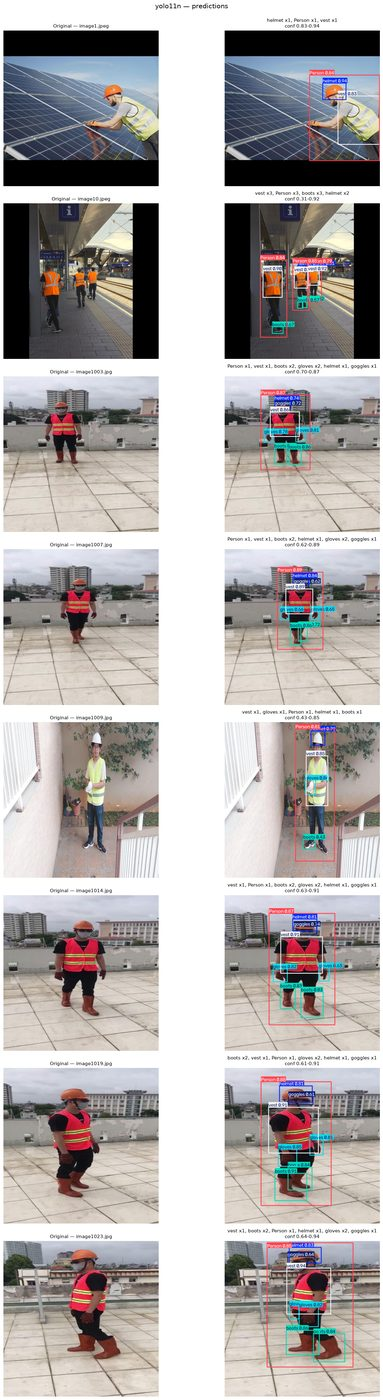

In [22]:
gallery = preds[:8]
fig, axes = plt.subplots(len(gallery), 2, figsize=(15, 5.1*len(gallery)))
if len(gallery) == 1:
    axes = np.array([axes])
for row, r in zip(axes, gallery):
    row[0].imshow(cv2.cvtColor(cv2.imread(r.path), cv2.COLOR_BGR2RGB))
    row[0].set_title(f"Original — {Path(r.path).name}", fontsize=10); row[0].axis("off")
    row[1].imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    if len(r.boxes):
        f_ = Counter(CLASS_NAMES[int(c)] for c in r.boxes.cls.tolist())
        t = ", ".join(f"{k} x{v}" for k, v in f_.items()) + chr(10) + \
            f"conf {r.boxes.conf.min():.2f}-{r.boxes.conf.max():.2f}"
    else:
        t = "nothing detected"
    row[1].set_title(t, fontsize=10); row[1].axis("off")
fig.suptitle(f"{RUN_NAME} — predictions", fontsize=14, y=0.999)
plt.tight_layout(); plt.show()

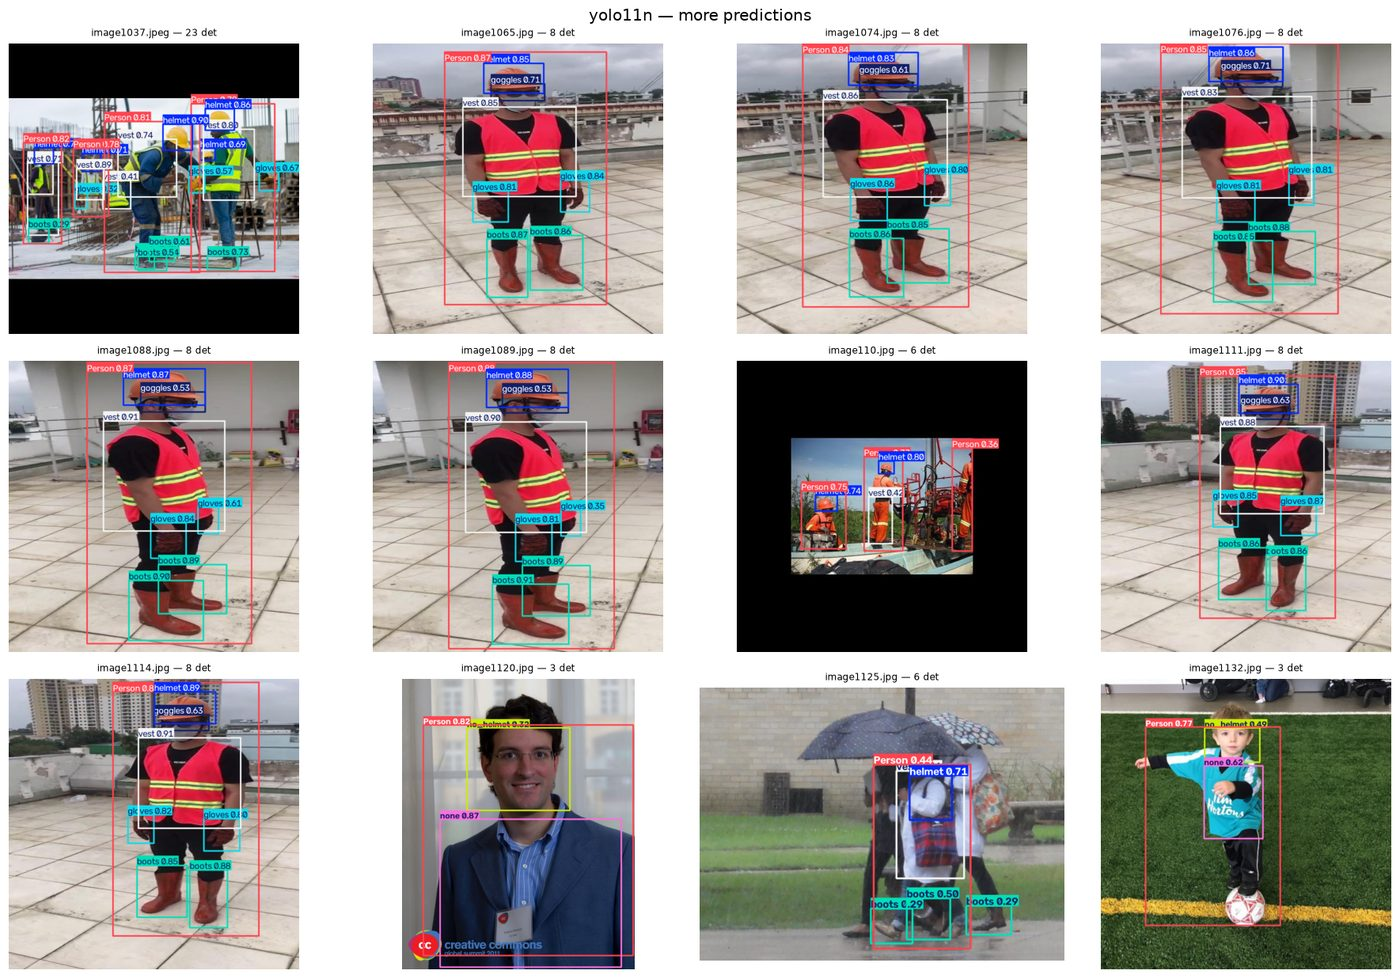

In [23]:
grid = preds[8:20]
rows = (len(grid)+3)//4
fig, axes = plt.subplots(rows, 4, figsize=(17, 3.8*rows))
for ax, r in zip(axes.ravel(), grid):
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(f"{Path(r.path).name} — {len(r.boxes)} det", fontsize=8); ax.axis("off")
for ax in axes.ravel()[len(grid):]:
    ax.axis("off")
fig.suptitle(f"{RUN_NAME} — more predictions", fontsize=13)
plt.tight_layout(); plt.show()

In [24]:
report = {
    "run_name": RUN_NAME, "base_weights": str(OG_WEIGHTS),
    "parameters_M": round(n_params/1e6, 2),
    "gpu_available": GPU_AVAILABLE, "gpu_type": GPU_TYPE, "gpu_name": GPU_NAME,
    "device": DEVICE, "host": HOST,
    "epochs_configured": EPOCHS, "epochs_ran": len(epoch_times),
    "batch": BATCH, "imgsz": IMGSZ, "amp": AMP,
    "train_minutes": round(elapsed/60, 1),
    "metrics": summary, "per_class": per_class.to_dict(orient="records"),
    "latency": {str(k): v for k, v in bench.items()},
    "thermal": {"cooldowns": guard["cooldowns"],
                "mean_epoch_s": float(np.mean(epoch_times or [0]))},
    "saved_weights": saved, "artifacts": exports,
}
(RUNS_DIR / f"{RUN_NAME}_report.json").write_text(json.dumps(report, indent=2))

ref = max(bench)
print("=" * 64)
print(f"  {RUN_NAME.upper()}  —  {'GPU (' + str(GPU_TYPE) + ')' if GPU_AVAILABLE else 'CPU'}")
print("=" * 64)
print(f"  Trained      {len(epoch_times)} epochs in {elapsed/60:.1f} min")
print(f"  Model size   {BEST.stat().st_size/1024**2:.2f} MB ({n_params/1e6:.2f} M params)")
print()
print(f"  mAP50        {summary['mAP50']:.4f}")
print(f"  mAP50-95     {summary['mAP50-95']:.4f}")
print(f"  Precision    {summary['precision']:.4f}")
print(f"  Recall       {summary['recall']:.4f}")
print()
print(f"  Speed        {bench[ref]['fps']:.1f} FPS @ {ref}px on {DEVICE}")
print(f"  Realtime     {'YES' if bench[ref]['fps'] >= 30 else 'NO'}")
print()
print(f"  Strongest    {', '.join(per_class.head(3)['class'])}")
print(f"  Weakest      {', '.join(per_class.tail(3)['class'])}")
print()
print(f"  og_model/       {MODEL_NAME}")
print(f"  trained_model/  {', '.join(Path(v).name for v in saved.values())}")
print(f"  predictions/    {PRED_DIR.name}/  ({len(preds)} images)")
print("=" * 64)

  YOLO11N  —  GPU (mps)
  Trained      0 epochs in 0.0 min
  Model size   5.22 MB (2.62 M params)

  mAP50        0.5704
  mAP50-95     0.2841
  Precision    0.7028
  Recall       0.5233

  Speed        100.2 FPS @ 640px on mps
  Realtime     YES

  Strongest    vest, Person, boots
  Weakest      no_gloves, no_goggle, no_boots

  og_model/       yolo11n.pt
  trained_model/  yolo11n_best.pt, yolo11n_last.pt
  predictions/    yolo11n/  (141 images)


## 17. Try your own image

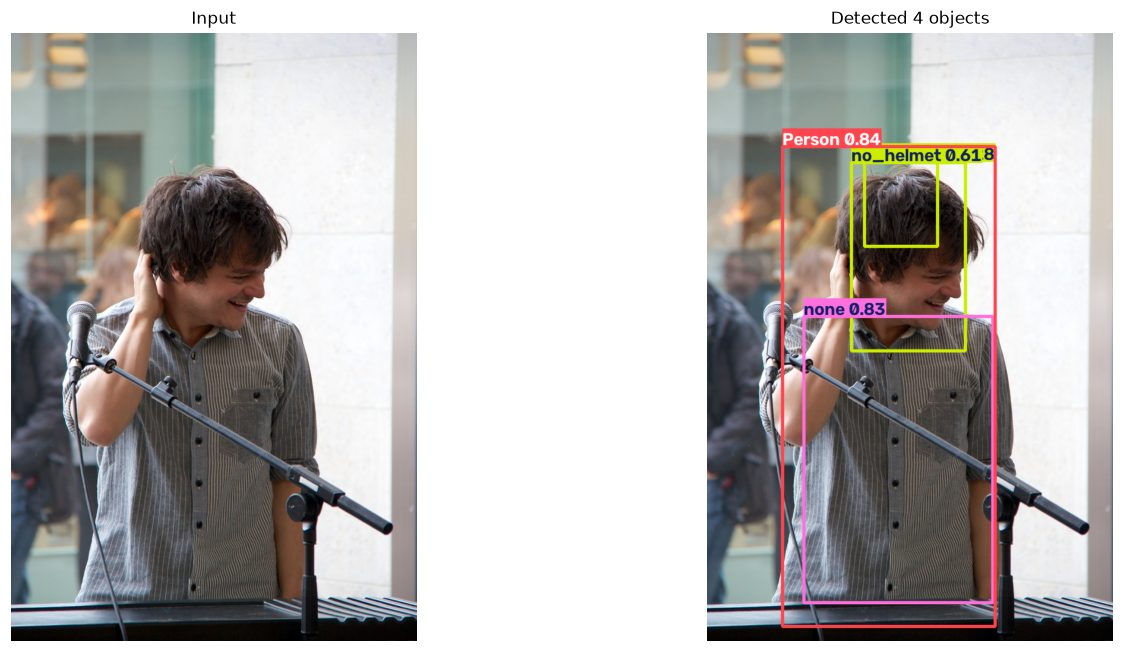

,class,confidence
0,Person,0.844
1,none,0.828
2,no_helmet,0.612
3,no_helmet,0.279


In [25]:
MY_IMAGE = None   # e.g. r"C:\Users\you\Desktop\site.jpg"  or "/Users/you/site.jpg"

src = MY_IMAGE or str(test_images[20])
r = best_model.predict(src, imgsz=IMGSZ, device=DEVICE, conf=0.25, verbose=False)[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(cv2.imread(src), cv2.COLOR_BGR2RGB))
axes[0].set_title("Input"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Detected {len(r.boxes)} objects"); axes[1].axis("off")
plt.tight_layout(); plt.show()

if len(r.boxes):
    display(pd.DataFrame([{"class": CLASS_NAMES[int(c)], "confidence": round(float(cf),3)}
                          for c, cf in zip(r.boxes.cls.tolist(), r.boxes.conf.tolist())]
                        ).sort_values("confidence", ascending=False).reset_index(drop=True))
else:
    print("Nothing detected above the threshold.")

---

# 18. Live camera

Live webcam detection in a window. Missing-PPE boxes are **red** and counted top-right.

Capture runs in a background thread. That matters more than model speed here: a plain
`read -> infer -> draw` loop blocks ~35 ms on `cap.read()` and the driver queues frames
while inference runs, so `read()` keeps handing back *older* frames and the lag grows the
longer you watch. Reading continuously in a thread drains that queue and the main loop
always takes the newest frame.

Measured on this machine: **22 FPS serial vs 118 FPS threaded**, and the display now
tracks the camera exactly rather than falling behind.

### Controls

| Key | Action | Key | Action |
|---|---|---|---|
| `Q` / `ESC` | quit | `SPACE` | pause |
| `+` / `-` | confidence | `[` / `]` | input size |
| `M` | next model | `B` | boxes on/off |
| `S` | save snapshot | `H` | toggle help |

In [26]:
import ppe_lib as ppe

cams = ppe.list_cameras()
print("Available camera indices:", cams if cams else "none detected")

# Load all three so M cycles between them live.
live_models = {n: ppe.Detector(n, conf=0.35, verbose=False) for n in ppe.MODELS}
live = live_models[RUN_NAME]
print(f"loaded {len(live_models)} models — press M in the window to cycle")

Available camera indices: [0]
loaded 4 models — press M in the window to cycle


In [27]:
CAMERA    = 0        # pick from the indices printed above
CONF_LIVE = 0.35     # adjustable live with + / -

# ---- UNCOMMENT THE NEXT LINE TO OPEN THE CAMERA WINDOW ----
# ppe.live_camera(live, camera=CAMERA, conf=CONF_LIVE, models=live_models)

print("Ready. Uncomment the ppe.live_camera(...) line above, then re-run this cell.")
print(f"  model  : {live.spec['label']}   (M cycles through all three)")
print(f"  camera : {CAMERA}")
print(f"  device : {live.backend.upper()}")
print()
print("  Q quit | SPACE pause | +/- conf | [ ] size | M model | B boxes | S save | H help")

Ready. Uncomment the ppe.live_camera(...) line above, then re-run this cell.
  model  : YOLO11 nano   (M cycles through all three)
  camera : 0
  device : MPS

  Q quit | SPACE pause | +/- conf | [ ] size | M model | B boxes | S save | H help
